# Week 4

# Data Loading

In [3]:
import pandas as pd

df = pd.read_csv("output.csv")

### Some common EDA

In [4]:
date_cols = ['Date of Admission', 'Discharge Date']
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  object        
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  object        
 3   Blood Type          54966 non-null  object        
 4   Medical Condition   54966 non-null  object        
 5   Date of Admission   54966 non-null  datetime64[ns]
 6   Doctor              54966 non-null  object        
 7   Hospital            54966 non-null  object        
 8   Insurance Provider  54966 non-null  object        
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  object        
 12  Discharge Date      54966 non-null  datetime64[ns]
 13  Medication          54966 non-null  object    

In [5]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
row, col=df.shape
print("Row: ",row)
print("Columns: ",col)

Row:  54966
Columns:  15


In [7]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,54966.000000,54966,54966.000000,54966.000000,54966
mean,51.535185,2021-11-01 17:35:29.505512448,25546.244286,301.124404,2021-11-17 05:34:28.202161408
min,13.000000,2019-05-08 00:00:00,9.238787,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13243.718641,202.000000,2020-08-13 00:00:00
50%,52.000000,2021-11-02 00:00:00,25542.749145,302.000000,2021-11-18 00:00:00
75%,68.000000,2023-02-03 00:00:00,37819.858159,401.000000,2023-02-19 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.605661,NaN,14204.924891,115.223143,NaN


In [8]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
# Filters and returns only the duplicate rows
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)


Empty DataFrame
Columns: [Name, Age, Gender, Blood Type, Medical Condition, Date of Admission, Doctor, Hospital, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results]
Index: []


In [11]:
unique_counts = df.nunique()
print(unique_counts)

Name                  49992
Age                      77
Gender                    2
Blood Type                8
Medical Condition         6
Date of Admission      1827
Doctor                40341
Hospital              39876
Insurance Provider        5
Billing Amount        50000
Room Number             400
Admission Type            3
Discharge Date         1856
Medication                5
Test Results              3
dtype: int64


# Statistical Analysis and Predictive Modeling

In [19]:
import seaborn as sns
sns.set(style="whitegrid")

In [12]:
df[['Age', 'Billing Amount']].describe()

,Age,Billing Amount
count,54966.000000,54966.000000
mean,51.535185,25546.244286
std,19.605661,14204.924891
min,13.000000,9.238787
25%,35.000000,13243.718641
50%,52.000000,25542.749145
75%,68.000000,37819.858159
max,89.000000,52764.276736


In [13]:
df['Medical Condition'].value_counts()

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

In [14]:
df['Gender'].value_counts()

Gender
Male      27496
Female    27470
Name: count, dtype: int64

In [15]:
df['Admission Type'].value_counts()

Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

In [16]:
df['Blood Type'].value_counts()

Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64

In [17]:
df['Test Results'].value_counts()

Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64

In [18]:
df[['Age','Billing Amount']].corr()

,Age,Billing Amount
Age,1.00000,-0.00341
Billing Amount,-0.00341,1.00000


# Predictive Modeling

### ==========================================
### Healthcare Predictive Modeling
### Compare Decision Tree, Random Forest,
### and Logistic Regression
### ==========================================

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

### Feature Selection

In [26]:
features = [
    "Age",    
    "Billing Amount",
    "Medical Condition"
]

target = "Test Results"

X = df[features].copy()
y = df[target].copy()

### Encode Categorical Columns

In [27]:
encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

### Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


### Models

In [29]:
models = {
    "Decision Tree": DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
),

    "Random Forest":RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
),

    "Logistic Regression": LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    multi_class="multinomial"
),
    "XGBClassifier": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05, random_state=42)
}

### Train & Evaluate

Decision Tree

Accuracy : 0.3317

Classification Report

              precision    recall  f1-score   support

    Abnormal       0.33      0.64      0.44      3688
Inconclusive       0.33      0.18      0.23      3640
      Normal       0.34      0.18      0.24      3666

    accuracy                           0.33     10994
   macro avg       0.33      0.33      0.30     10994
weighted avg       0.33      0.33      0.30     10994



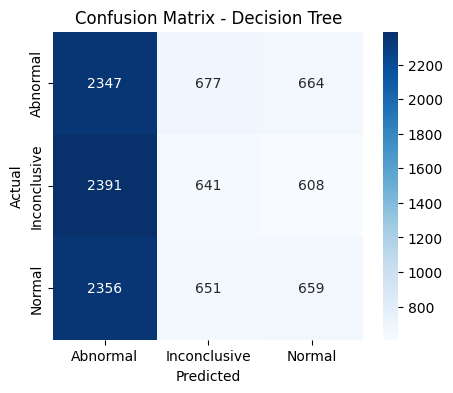

             Feature  Importance
1     Billing Amount    0.727685
0                Age    0.234990
2  Medical Condition    0.037324
Random Forest

Accuracy : 0.3516

Classification Report

              precision    recall  f1-score   support

    Abnormal       0.36      0.37      0.36      3688
Inconclusive       0.34      0.34      0.34      3640
      Normal       0.36      0.35      0.35      3666

    accuracy                           0.35     10994
   macro avg       0.35      0.35      0.35     10994
weighted avg       0.35      0.35      0.35     10994



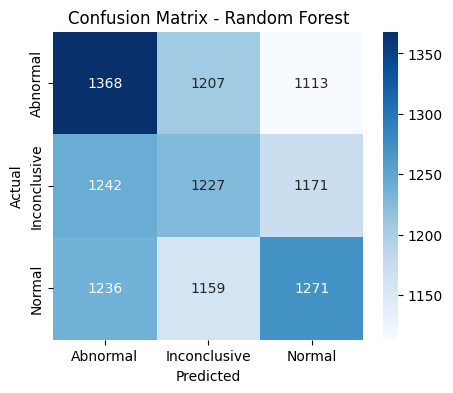

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\

Logistic Regression

Accuracy : 0.3355

Classification Report

              precision    recall  f1-score   support

    Abnormal       0.34      1.00      0.50      3688
Inconclusive       0.00      0.00      0.00      3640
      Normal       0.00      0.00      0.00      3666

    accuracy                           0.34     10994
   macro avg       0.11      0.33      0.17     10994
weighted avg       0.11      0.34      0.17     10994



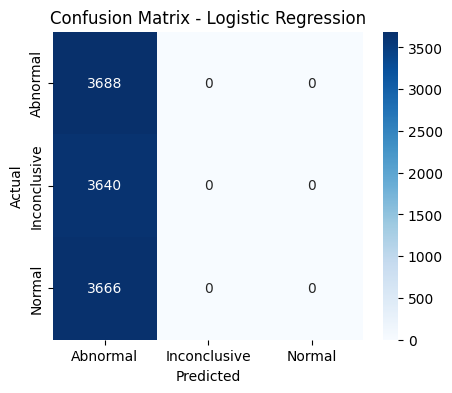

XGBClassifier

Accuracy : 0.3446

Classification Report

              precision    recall  f1-score   support

    Abnormal       0.35      0.40      0.38      3688
Inconclusive       0.33      0.31      0.32      3640
      Normal       0.35      0.32      0.33      3666

    accuracy                           0.34     10994
   macro avg       0.34      0.34      0.34     10994
weighted avg       0.34      0.34      0.34     10994



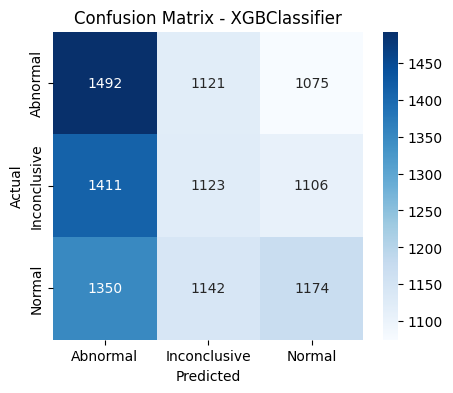

In [32]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    if name == "Random Forest":
        importance = pd.DataFrame({
            "Feature": X.columns,
            "Importance": model.feature_importances_
        }).sort_values(by="Importance", ascending=False)
        print(importance)
        
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nAccuracy :", round(accuracy,4))

    print("\nClassification Report\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### Comparison Table

In [33]:
results_df = pd.DataFrame(results)

print("\n")
print(results_df)



                 Model  Accuracy  Precision    Recall  F1-Score
0        Decision Tree  0.331726   0.332567  0.331726  0.300240
1        Random Forest  0.351646   0.351604  0.351646  0.351539
2  Logistic Regression  0.335456   0.112531  0.335456  0.168528
3        XGBClassifier  0.344643   0.344175  0.344643  0.343410


### Best Model

In [34]:
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("\nBest Model")
print(best_model)


Best Model
Model        Random Forest
Accuracy          0.351646
Precision         0.351604
Recall            0.351646
F1-Score          0.351539
Name: 1, dtype: object


### Accuracy Comparison Plot

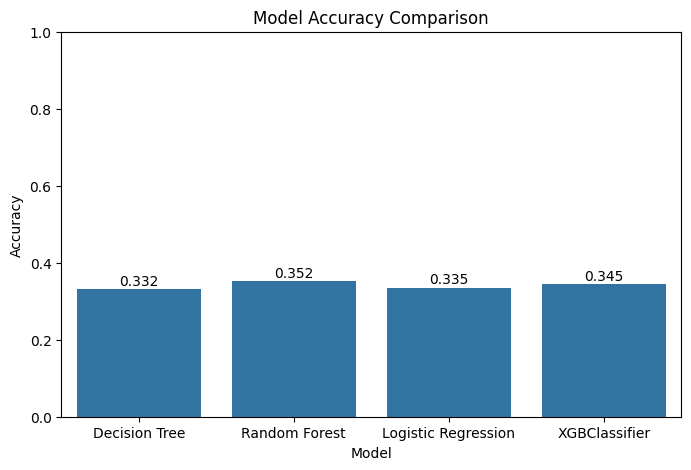

In [35]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

for i,v in enumerate(results_df["Accuracy"]):
    plt.text(i,v+0.01,f"{v:.3f}",ha="center")

plt.show()

# Thank You